# 3. Manual Neural Network for Nonlinear Regression

We solve Question 3 from Midterm 2 by implementing the requested neural network directly from first principles.

The prescribed data-generating process is

$$
x_1,x_2\sim U(-2,2),
\qquad
\varepsilon\sim\mathcal N(0,0.15^2),
$$

$$
f(x_1,x_2)=\max\left\{0,\;1.5+2\sin(\pi x_1)+0.75x_2^2-1.2x_1x_2\right\},
$$

and

$$
y=\max\{0,f(x_1,x_2)+\varepsilon\}.
$$

The required manual model has two inputs, two hidden layers with two neurons each, one output neuron, and ReLU activation in every neuron including the output neuron. The extra-credit comparison is included at the end using a high-level dense neural network.

---

## 3.1. Objects, dimensions, and notation

For a mini-batch or full batch of $m$ observations, define

$$
X=\begin{bmatrix}
x_{11} & x_{12}\\
\vdots & \vdots\\
x_{m1} & x_{m2}
\end{bmatrix}\in\mathbb R^{m\times 2},
\qquad
 y\in\mathbb R^{m\times 1}.
$$

The trainable parameters are

$$
W^{(1)}\in\mathbb R^{2\times 2},\quad b^{(1)}\in\mathbb R^{1\times 2},
$$

$$
W^{(2)}\in\mathbb R^{2\times 2},\quad b^{(2)}\in\mathbb R^{1\times 2},
$$

$$
W^{(3)}\in\mathbb R^{2\times 1},\quad b^{(3)}\in\mathbb R^{1\times 1}.
$$

Therefore the total number of trainable scalar parameters is

$$
2\cdot2+2+2\cdot2+2+2\cdot1+1=15.
$$

This small parameter count is important for interpretation: every scalar weight and bias can be inspected, and every gradient is computed explicitly.

## 3.2. Forward propagation

Let the ReLU activation be

$$
\rho(u)=\max\{0,u\}.
$$

For the full batch $X$, forward propagation is

$$
Z^{(1)}=XW^{(1)}+\mathbf 1 b^{(1)},
\qquad
A^{(1)}=\rho\left(Z^{(1)}\right),
$$

$$
Z^{(2)}=A^{(1)}W^{(2)}+\mathbf 1 b^{(2)},
\qquad
A^{(2)}=\rho\left(Z^{(2)}\right),
$$

$$
Z^{(3)}=A^{(2)}W^{(3)}+\mathbf 1 b^{(3)},
\qquad
\widehat y=\rho\left(Z^{(3)}\right).
$$

Here $\mathbf 1$ denotes a column vector of ones with $m$ entries. In NumPy, this addition is implemented by broadcasting the row-vector biases across the batch dimension.

## 3.3. Error function and update-sign convention

The question writes the parameter update as

$$
w_{new}=w_{old}+\lambda\nabla_w.
$$

In standard optimization notation, the gradient of a loss points in the direction of steepest increase of that loss. Therefore, for the ordinary positive squared-error objective

$$
J(\theta)=\frac{1}{2m}\sum_{i=1}^m \left(y_i-\widehat y_i\right)^2,
$$

the standard gradient-descent update is

$$
\theta \leftarrow \theta-\lambda\frac{\partial J}{\partial\theta}.
$$

This is equivalent to the statement in the question if its symbol $\nabla_w$ is read as the descent direction

$$
\nabla_w=-\frac{\partial J}{\partial w}.
$$

With this convention, the notebook uses the standard loss $J\ge 0$, computes the ordinary derivatives $\partial J/\partial\theta$, and updates every weight and bias by subtracting the corresponding gradient.

## 3.4. Backpropagation derivation

Let

$$
r=\widehat y-y\in\mathbb R^{m\times 1}.
$$

Because

$$
J=\frac{1}{2m}\sum_{i=1}^m (\widehat y_i-y_i)^2,
$$

we have

$$
\frac{\partial J}{\partial \widehat y}=\frac{1}{m}(\widehat y-y)=\frac{1}{m}r.
$$

For ReLU we use the standard subgradient

$$
\rho'(u)=\begin{cases}
1, & u>0,\\
0, & u\le 0.
\end{cases}
$$

The output-layer error signal is

$$
\Delta^{(3)}=\frac{\partial J}{\partial Z^{(3)}}=\frac{1}{m}r\odot \rho'\left(Z^{(3)}\right)
\in\mathbb R^{m\times 1}.
$$

Then the gradients for the output layer are

$$
\frac{\partial J}{\partial W^{(3)}}=(A^{(2)})^\top\Delta^{(3)}\in\mathbb R^{2\times 1},
\qquad
\frac{\partial J}{\partial b^{(3)}}=\mathbf 1^\top\Delta^{(3)}\in\mathbb R^{1\times 1}.
$$

The second hidden-layer signal is

$$
\Delta^{(2)}=\left(\Delta^{(3)}(W^{(3)})^\top\right)\odot \rho'\left(Z^{(2)}\right)
\in\mathbb R^{m\times 2},
$$

with gradients

$$
\frac{\partial J}{\partial W^{(2)}}=(A^{(1)})^\top\Delta^{(2)}\in\mathbb R^{2\times 2},
\qquad
\frac{\partial J}{\partial b^{(2)}}=\mathbf 1^\top\Delta^{(2)}\in\mathbb R^{1\times 2}.
$$

The first hidden-layer signal is

$$
\Delta^{(1)}=\left(\Delta^{(2)}(W^{(2)})^\top\right)\odot \rho'\left(Z^{(1)}\right)
\in\mathbb R^{m\times 2},
$$

with gradients

$$
\frac{\partial J}{\partial W^{(1)}}=X^\top\Delta^{(1)}\in\mathbb R^{2\times 2},
\qquad
\frac{\partial J}{\partial b^{(1)}}=\mathbf 1^\top\Delta^{(1)}\in\mathbb R^{1\times 2}.
$$

These equations are the complete ordinary loss gradient for each parameter block in the requested architecture. The descent direction used in the assignment's plus-sign update is the negative of these gradients.

## 3.5. Imports and reproducibility

The manual neural network uses only NumPy. Pandas and Matplotlib are used for tables and plots. The optional high-level comparison uses Keras with the JAX backend, which is available in this repository environment.

In [1]:
import os
import time
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

## 3.6. Data simulation

We simulate exactly $n=3000$ independent observations from the distribution specified in the question. The function `simulate_data` returns both the noiseless signal $f$ and the observed clipped target $y$, because the final evaluation must compare the fitted model against both.

In [2]:
def true_signal(X_raw: np.ndarray) -> np.ndarray:
    """Evaluate the noiseless clipped regression function f(x1, x2)."""
    x1 = X_raw[:, [0]]
    x2 = X_raw[:, [1]]
    raw_signal = 1.5 + 2.0 * np.sin(np.pi * x1) + 0.75 * x2**2 - 1.2 * x1 * x2
    return np.maximum(0.0, raw_signal)


def simulate_data(n: int = 3000, seed: int = 123) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate X, noiseless f(X), and noisy clipped target y."""
    local_rng = np.random.default_rng(seed)
    X_raw = local_rng.uniform(-2.0, 2.0, size=(n, 2))
    epsilon = local_rng.normal(loc=0.0, scale=0.15, size=(n, 1))
    f = true_signal(X_raw)
    y = np.maximum(0.0, f + epsilon)
    return X_raw, f, y


X_raw, f_true, y = simulate_data(n=3000, seed=SEED)

print("X_raw shape:", X_raw.shape)
print("f_true shape:", f_true.shape)
print("y shape:", y.shape)
print("x1 range:", (float(X_raw[:, 0].min()), float(X_raw[:, 0].max())))
print("x2 range:", (float(X_raw[:, 1].min()), float(X_raw[:, 1].max())))
print("observed y range:", (float(y.min()), float(y.max())))

X_raw shape: (3000, 2)
f_true shape: (3000, 1)
y shape: (3000, 1)
x1 range: (-1.9999130966022673, 1.9953263300383108)
x2 range: (-1.9992544808909254, 1.999413340676028)
observed y range: (0.0, 10.108856070323368)


## 3.7. Train, validation, and test split

The parameters are fit on the training set, the best random restart is selected by validation MSE, and the final metrics are reported on a held-out test set. Inputs are standardized using training-set statistics only:

$$
\widetilde x_j=\frac{x_j-\mu_j}{\sigma_j}.
$$

The target is not standardized. It remains on the same nonnegative scale as the ReLU output.

In [3]:
def split_indices(n: int, train_frac: float = 0.70, val_frac: float = 0.15, seed: int = 123):
    """Return deterministic train, validation, and test indices."""
    local_rng = np.random.default_rng(seed)
    idx = local_rng.permutation(n)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    train_idx = idx[:n_train]
    val_idx = idx[n_train : n_train + n_val]
    test_idx = idx[n_train + n_val :]
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = split_indices(X_raw.shape[0], seed=SEED)

X_train_raw, X_val_raw, X_test_raw = X_raw[train_idx], X_raw[val_idx], X_raw[test_idx]
f_train, f_val, f_test = f_true[train_idx], f_true[val_idx], f_true[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

x_mean = X_train_raw.mean(axis=0, keepdims=True)
x_std = X_train_raw.std(axis=0, keepdims=True)

X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

print("Training observations:", X_train.shape[0])
print("Validation observations:", X_val.shape[0])
print("Test observations:", X_test.shape[0])
print("Training mean used for scaling:", x_mean.ravel())
print("Training std used for scaling:", x_std.ravel())

Training observations: 2100
Validation observations: 450
Test observations: 450
Training mean used for scaling: [-0.05688475 -0.0179091 ]
Training std used for scaling: [1.15152588 1.12939735]


## 3.8. Visual check of the simulated nonlinearity

The plots below are not used for training. They verify that the simulated target is nonlinear, nonnegative, and affected by noise.

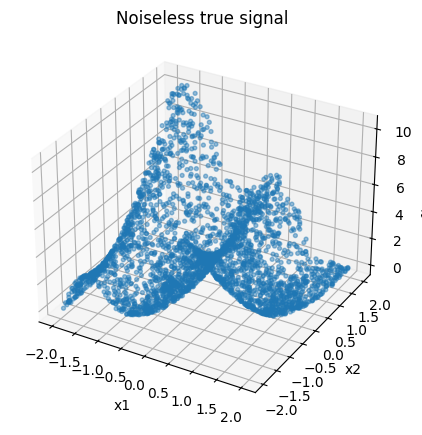

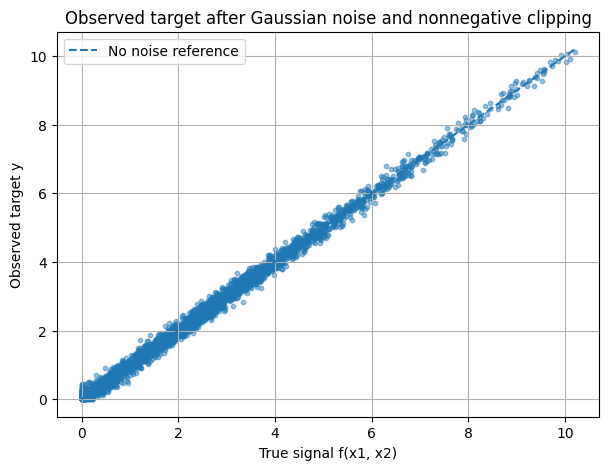

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_raw[:, 0], X_raw[:, 1], f_true.ravel(), s=8, alpha=0.45)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")
ax.set_title("Noiseless true signal")
plt.show()

plt.figure()
plt.scatter(f_true.ravel(), y.ravel(), s=10, alpha=0.45)
lo = min(float(f_true.min()), float(y.min()))
hi = max(float(f_true.max()), float(y.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", label="No noise reference")
plt.xlabel("True signal f(x1, x2)")
plt.ylabel("Observed target y")
plt.title("Observed target after Gaussian noise and nonnegative clipping")
plt.legend()
plt.show()

## 3.9. Manual implementation

The implementation below mirrors the formulas derived above. The computational core has no side effects: forward propagation, loss, gradients, and parameter updates are separate functions. This makes the manual contract auditable.

In [5]:
ParameterDict = Dict[str, np.ndarray]


def relu(z: np.ndarray) -> np.ndarray:
    """Elementwise ReLU activation."""
    return np.maximum(0.0, z)


def drelu(z: np.ndarray) -> np.ndarray:
    """Elementwise ReLU derivative, using 0 as the subgradient at z = 0."""
    return (z > 0.0).astype(float)


def initialize_parameters(seed: int, y_reference: np.ndarray) -> ParameterDict:
    """Initialize all 15 trainable parameters of the requested network."""
    local_rng = np.random.default_rng(seed)
    return {
        "W1": local_rng.normal(loc=0.0, scale=np.sqrt(2.0 / 2.0), size=(2, 2)),
        "b1": np.full((1, 2), 0.10),
        "W2": local_rng.normal(loc=0.0, scale=np.sqrt(2.0 / 2.0), size=(2, 2)),
        "b2": np.full((1, 2), 0.10),
        "W3": local_rng.normal(loc=0.0, scale=np.sqrt(2.0 / 2.0), size=(2, 1)),
        "b3": np.array([[float(y_reference.mean())]]),
    }


def forward_propagation(X: np.ndarray, params: ParameterDict):
    """Compute every pre-activation, activation, and final prediction."""
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ params["W3"] + params["b3"]
    y_hat = relu(Z3)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "y_hat": y_hat}
    return y_hat, cache


def mse_loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean squared error, reported as the loss scale for interpretation."""
    return float(np.mean((y_true - y_pred) ** 2))


def compute_gradients(cache: Dict[str, np.ndarray], y_true: np.ndarray, params: ParameterDict) -> ParameterDict:
    """Compute gradients of J = 1/(2m) sum_i (yhat_i - y_i)^2 for all parameters."""
    X = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    Z3, y_hat = cache["Z3"], cache["y_hat"]

    m = y_true.shape[0]
    residual = y_hat - y_true

    delta3 = (residual / m) * drelu(Z3)
    grad_W3 = A2.T @ delta3
    grad_b3 = np.sum(delta3, axis=0, keepdims=True)

    delta2 = (delta3 @ params["W3"].T) * drelu(Z2)
    grad_W2 = A1.T @ delta2
    grad_b2 = np.sum(delta2, axis=0, keepdims=True)

    delta1 = (delta2 @ params["W2"].T) * drelu(Z1)
    grad_W1 = X.T @ delta1
    grad_b1 = np.sum(delta1, axis=0, keepdims=True)

    return {"W1": grad_W1, "b1": grad_b1, "W2": grad_W2, "b2": grad_b2, "W3": grad_W3, "b3": grad_b3}


def update_parameters(params: ParameterDict, gradients: ParameterDict, learning_rate: float) -> ParameterDict:
    """Apply standard gradient descent: theta_new = theta_old - lambda * dJ/dtheta."""
    return {name: params[name] - learning_rate * gradients[name] for name in params}


def count_parameters(params: ParameterDict) -> int:
    """Count trainable scalar parameters in a parameter dictionary."""
    return int(sum(value.size for value in params.values()))


initial_params = initialize_parameters(seed=SEED, y_reference=y_train)
print("Manual parameter shapes:")
for name, value in initial_params.items():
    print(f"{name}: {value.shape}")
print("Total manual parameters:", count_parameters(initial_params))

Manual parameter shapes:
W1: (2, 2)
b1: (1, 2)
W2: (2, 2)
b2: (1, 2)
W3: (2, 1)
b3: (1, 1)
Total manual parameters: 15


## 3.10. Gradient check

Before training, we verify the manual backpropagation against finite differences for a randomly selected set of scalar parameters. This is a focused numerical check of the derived gradient signs and shapes.

For a scalar parameter $\theta_j$, the finite-difference approximation is

$$
\frac{\partial J}{\partial \theta_j}\approx
\frac{J(\theta_j+h)-J(\theta_j-h)}{2h}.
$$

The relative error should be small up to numerical precision and ReLU nonsmoothness.

In [6]:
def objective_J(X_batch: np.ndarray, y_batch: np.ndarray, params: ParameterDict) -> float:
    """Return J = 1/(2m) SSE, the standard positive half-MSE objective."""
    prediction, _ = forward_propagation(X_batch, params)
    residual = prediction - y_batch
    return float(0.5 * np.mean(residual**2))


def copy_params(params: ParameterDict) -> ParameterDict:
    """Deep-copy a parameter dictionary."""
    return {name: value.copy() for name, value in params.items()}


def finite_difference_check(
    X_batch: np.ndarray,
    y_batch: np.ndarray,
    params: ParameterDict,
    checks_per_block: int = 3,
    h: float = 1e-5,
    seed: int = 123,
) -> pd.DataFrame:
    """Compare analytic gradients with central finite differences."""
    local_rng = np.random.default_rng(seed)
    _, cache = forward_propagation(X_batch, params)
    analytic = compute_gradients(cache, y_batch, params)
    rows = []

    for name, block in params.items():
        flat_indices = local_rng.choice(block.size, size=min(checks_per_block, block.size), replace=False)
        for flat_index in flat_indices:
            index = np.unravel_index(flat_index, block.shape)

            plus = copy_params(params)
            minus = copy_params(params)
            plus[name][index] += h
            minus[name][index] -= h

            numerical = (objective_J(X_batch, y_batch, plus) - objective_J(X_batch, y_batch, minus)) / (2.0 * h)
            analytic_value = float(analytic[name][index])
            denom = max(1.0, abs(numerical), abs(analytic_value))
            rows.append(
                {
                    "parameter": name,
                    "index": index,
                    "analytic": analytic_value,
                    "finite_difference": numerical,
                    "absolute_error": abs(analytic_value - numerical),
                    "relative_error": abs(analytic_value - numerical) / denom,
                }
            )

    return pd.DataFrame(rows)


gradient_check_params = initialize_parameters(seed=11, y_reference=y_train)
gradient_check_table = finite_difference_check(
    X_train[:128],
    y_train[:128],
    gradient_check_params,
    checks_per_block=3,
    seed=SEED,
)
display(gradient_check_table)
print("Maximum relative error:", gradient_check_table["relative_error"].max())

,parameter,index,analytic,finite_difference,absolute_error,relative_error
0,W1,"(1, 1)",0.153520,0.153520,1.990380e-12,1.990380e-12
1,W1,"(1, 0)",-0.064879,-0.064879,6.874584e-12,6.874584e-12
2,W1,"(0, 0)",-0.105701,-0.105701,2.288447e-13,2.288447e-13
3,b1,"(0, 1)",0.200161,0.200161,6.667000e-12,6.667000e-12
4,b1,"(0, 0)",-0.091693,-0.091693,6.553133e-12,6.553133e-12
5,W2,"(0, 0)",0.308893,0.308893,6.568968e-12,6.568968e-12
6,W2,"(1, 1)",0.051749,0.051749,7.753596e-12,7.753596e-12
7,W2,"(0, 1)",0.000383,0.000383,1.024695e-11,1.024695e-11
8,b2,"(0, 0)",0.499908,0.499908,5.630607e-12,5.630607e-12
9,b2,"(0, 1)",-0.562115,-0.562115,9.069634e-12,9.069634e-12


Maximum relative error: 1.024694576152313e-11


## 3.11. Full-batch manual training

The network is intentionally tiny and uses ReLU in the output layer. Some random initializations may create inactive paths or poor local optima. To separate implementation correctness from a single unlucky initialization, the training procedure uses multiple deterministic restarts and selects the run with the lowest validation MSE.

The optimizer uses the standard gradient-descent update

$$
\theta \leftarrow \theta-\lambda\frac{\partial J}{\partial\theta}.
$$

This is the same algebraic movement as $w_{new}=w_{old}+\lambda\nabla_w$ when $\nabla_w$ denotes the descent direction $-\partial J/\partial w$.

In [7]:
def train_manual_network(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    learning_rate: float = 0.045,
    epochs: int = 7000,
    seeds: Iterable[int] = range(12),
    log_every: int = 100,
):
    """Train the manual network with full-batch gradient descent on J."""
    best = {"val_mse": np.inf, "seed": None, "params": None, "history": None, "elapsed_seconds": None}
    run_rows = []

    for seed in seeds:
        params = initialize_parameters(seed=seed, y_reference=y_train)
        history = []
        start = time.perf_counter()

        for epoch in range(epochs + 1):
            y_hat_train, cache = forward_propagation(X_train, params)

            if epoch % log_every == 0:
                y_hat_val, _ = forward_propagation(X_val, params)
                history.append(
                    {
                        "epoch": epoch,
                        "train_mse": mse_loss(y_train, y_hat_train),
                        "val_mse": mse_loss(y_val, y_hat_val),
                    }
                )

            if epoch < epochs:
                gradients = compute_gradients(cache, y_train, params)
                params = update_parameters(params, gradients, learning_rate)

        elapsed = time.perf_counter() - start
        y_hat_val, _ = forward_propagation(X_val, params)
        final_val_mse = mse_loss(y_val, y_hat_val)
        run_rows.append({"seed": seed, "val_mse": final_val_mse, "elapsed_seconds": elapsed})

        if final_val_mse < best["val_mse"]:
            best = {
                "val_mse": final_val_mse,
                "seed": seed,
                "params": copy_params(params),
                "history": pd.DataFrame(history),
                "elapsed_seconds": elapsed,
            }

    return best, pd.DataFrame(run_rows).sort_values("val_mse", ignore_index=True)


manual_best, manual_runs = train_manual_network(X_train, y_train, X_val, y_val)

print("Validation MSE by manual restart:")
display(manual_runs)
print("Best manual seed:", manual_best["seed"])
print("Best manual validation MSE:", manual_best["val_mse"])
print("Manual train time for best seed, seconds:", manual_best["elapsed_seconds"])
print("Manual parameter count:", count_parameters(manual_best["params"]))

Validation MSE by manual restart:


,seed,val_mse,elapsed_seconds
0,1,1.549852,1.406998
1,2,1.589131,1.382266
2,7,1.890093,1.360735
3,10,2.461948,1.357258
4,8,2.736335,1.371928
5,4,2.892518,1.403813
6,6,2.990040,1.363626
7,9,3.220692,1.346388
8,11,3.263334,1.354636
9,0,3.668376,1.372516


Best manual seed: 1
Best manual validation MSE: 1.5498521142689754
Manual train time for best seed, seconds: 1.4069977969993488
Manual parameter count: 15


## 3.12. Manual training curve

The curve reports MSE. Since the manual optimizer performs gradient descent on the positive half-MSE objective $J$, decreasing MSE is the expected behavior.

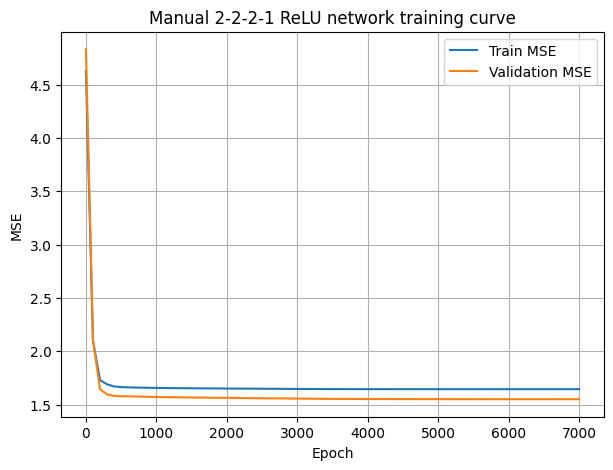

In [8]:
history = manual_best["history"]

plt.figure()
plt.plot(history["epoch"], history["train_mse"], label="Train MSE")
plt.plot(history["epoch"], history["val_mse"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Manual 2-2-2-1 ReLU network training curve")
plt.legend()
plt.show()

## 3.13. Regression metrics

The same test predictions are evaluated against two different targets:

1. observed $y$, which includes noise and clipping;
2. noiseless $f(x_1,x_2)$, which is the true signal before observational noise.

For target vector $t$ and predictions $\widehat t$, the reported metrics are

$$
\mathrm{MAE}=\frac{1}{n}\sum_i |t_i-\widehat t_i|,
$$

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_i (t_i-\widehat t_i)^2},
$$

and

$$
R^2=1-\frac{\sum_i(t_i-\widehat t_i)^2}{\sum_i(t_i-\bar t)^2}.
$$

In [9]:
def regression_metrics(target: np.ndarray, prediction: np.ndarray) -> Dict[str, float]:
    """Return MAE, RMSE, and R2 for column-vector targets and predictions."""
    residual = target - prediction
    mae = float(np.mean(np.abs(residual)))
    rmse = float(np.sqrt(np.mean(residual**2)))
    ss_res = float(np.sum(residual**2))
    ss_tot = float(np.sum((target - target.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


manual_yhat_test, _ = forward_propagation(X_test, manual_best["params"])
manual_metrics_observed = regression_metrics(y_test, manual_yhat_test)
manual_metrics_true = regression_metrics(f_test, manual_yhat_test)

manual_metrics_table = pd.DataFrame(
    [manual_metrics_observed, manual_metrics_true],
    index=["Manual NN vs observed y", "Manual NN vs true f"],
)
display(manual_metrics_table)

,MAE,RMSE,R2
Manual NN vs observed y,1.118758,1.276314,0.648190
Manual NN vs true f,1.122043,1.275854,0.649138


## 3.14. Prediction-versus-target plots

A perfect prediction would lie on the dashed diagonal. Systematic departures from the diagonal indicate bias or underfitting.

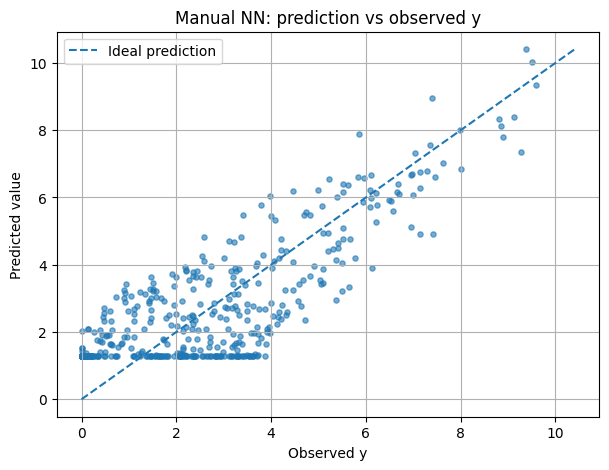

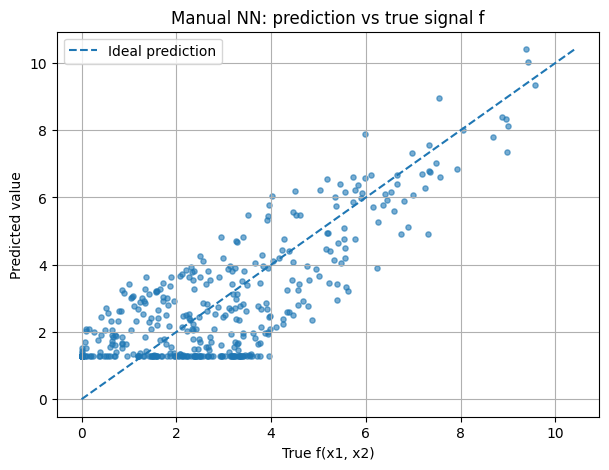

In [10]:
def prediction_plot(target: np.ndarray, prediction: np.ndarray, title: str, xlabel: str):
    """Plot predicted values against a selected target with an ideal diagonal."""
    target_flat = target.ravel()
    pred_flat = prediction.ravel()
    lo = min(float(target_flat.min()), float(pred_flat.min()))
    hi = max(float(target_flat.max()), float(pred_flat.max()))

    plt.figure()
    plt.scatter(target_flat, pred_flat, s=14, alpha=0.60)
    plt.plot([lo, hi], [lo, hi], linestyle="--", label="Ideal prediction")
    plt.xlabel(xlabel)
    plt.ylabel("Predicted value")
    plt.title(title)
    plt.legend()
    plt.show()


prediction_plot(y_test, manual_yhat_test, "Manual NN: prediction vs observed y", "Observed y")
prediction_plot(f_test, manual_yhat_test, "Manual NN: prediction vs true signal f", "True f(x1, x2)")

## 3.15. Residual diagnostics

The residuals are plotted against the model predictions. For a well-specified regression model, residuals should not show strong structure. Here some structure is expected because a 15-parameter ReLU network has limited capacity relative to the sinusoidal, quadratic, and interaction terms in the data-generating process.

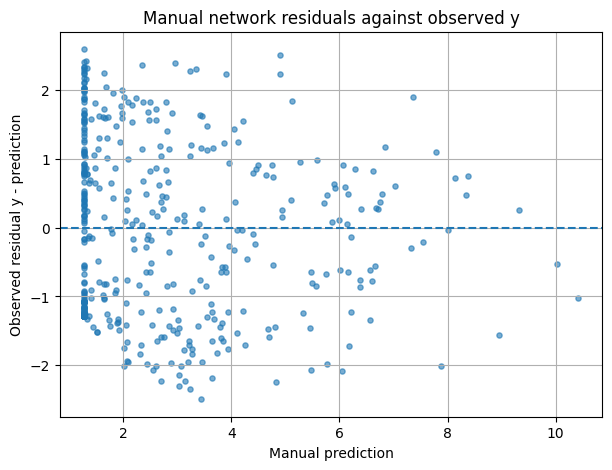

In [11]:
manual_residuals = y_test - manual_yhat_test

plt.figure()
plt.scatter(manual_yhat_test.ravel(), manual_residuals.ravel(), s=14, alpha=0.60)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Manual prediction")
plt.ylabel("Observed residual y - prediction")
plt.title("Manual network residuals against observed y")
plt.show()

## 3.16. Learned manual parameters

The final parameter values are printed so the solution is reproducible and auditable. These are the concrete weights and biases obtained by the explicit update rule.

In [12]:
for name, value in manual_best["params"].items():
    print(f"{name} shape {value.shape}")
    print(value)
    print()

W1 shape (2, 2)
[[-0.94313205  0.76872724]
 [ 1.17960918 -1.56022673]]

b1 shape (1, 2)
[[-0.4858817   0.33117686]]

W2 shape (2, 2)
[[ 1.437125    1.10220872]
 [-0.57747227  1.0216053 ]]

b2 shape (1, 2)
[[-9.24491728e-04 -1.66130614e+00]]

W3 shape (2, 1)
[[1.18988853]
 [2.13515348]]

b3 shape (1, 1)
[[1.28219402]]



## 3.17. Extra credit: high-level dense neural network

For the extra-credit comparison, we fit a larger dense ReLU network using Keras. The architecture is

$$
2\rightarrow 32\rightarrow 32\rightarrow 1,
$$

with ReLU nonlinearities and a ReLU output, so the output constraint is comparable to the manual network. This model has many more parameters and uses Adam, so it should usually fit the nonlinear surface more accurately and with greater optimization stability. The tradeoff is lower interpretability: gradients and updates are handled by the library rather than written out scalar by scalar.

In [13]:
high_level_result = None

try:
    os.environ.setdefault("KERAS_BACKEND", "jax")
    import keras

    keras.utils.set_random_seed(SEED)

    inputs = keras.Input(shape=(2,), name="x")
    hidden_1 = keras.layers.Dense(32, activation="relu", name="hidden_1")(inputs)
    hidden_2 = keras.layers.Dense(32, activation="relu", name="hidden_2")(hidden_1)
    outputs = keras.layers.Dense(1, activation="relu", name="output")(hidden_2)
    high_model = keras.Model(inputs=inputs, outputs=outputs, name="high_level_dense_relu")

    high_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=40,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]

    start = time.perf_counter()
    history_obj = high_model.fit(
        X_train.astype("float32"),
        y_train.astype("float32"),
        validation_data=(X_val.astype("float32"), y_val.astype("float32")),
        epochs=800,
        batch_size=128,
        verbose=0,
        callbacks=callbacks,
    )
    high_elapsed = time.perf_counter() - start

    high_yhat_test = np.asarray(high_model.predict(X_test.astype("float32"), verbose=0))
    high_history = pd.DataFrame(
        {
            "epoch": np.arange(1, len(history_obj.history["loss"]) + 1),
            "train_mse": history_obj.history["loss"],
            "val_mse": history_obj.history["val_loss"],
        }
    )

    high_level_result = {
        "library": f"Keras ({keras.backend.backend()} backend)",
        "prediction": high_yhat_test,
        "history": high_history,
        "elapsed_seconds": high_elapsed,
        "param_count": high_model.count_params(),
        "best_val_mse": float(high_history["val_mse"].min()),
    }

    print("High-level library:", high_level_result["library"])
    print("High-level parameter count:", high_level_result["param_count"])
    print("Best high-level validation MSE:", high_level_result["best_val_mse"])
    print("High-level elapsed seconds:", high_level_result["elapsed_seconds"])

except Exception as exc:
    print("The high-level comparison was skipped because Keras/JAX is unavailable or failed.")
    print("Reason:", repr(exc))

High-level library: Keras (jax backend)
High-level parameter count: 1185
Best high-level validation MSE: 0.021680979058146477
High-level elapsed seconds: 3.10483404399929


## 3.18. Manual versus high-level comparison

The comparison below uses the same train, validation, and test split. The main differences are model capacity and optimizer:

- the manual model has exactly 15 parameters and uses explicit full-batch gradient descent on $J$;
- the high-level model has many more parameters and uses Adam;
- both models preserve the nonnegative output by using a ReLU output layer.

,Model,Parameters,"Training time, s",Target compared,MAE,RMSE,R2
0,Manual 2-2-2-1 ReLU NN,15,1.406998,observed y,1.118758,1.276314,0.648190
1,Manual 2-2-2-1 ReLU NN,15,1.406998,true f,1.122043,1.275854,0.649138
2,High-level 2-32-32-1 ReLU NN,1185,3.104834,observed y,0.123574,0.160875,0.994411
3,High-level 2-32-32-1 ReLU NN,1185,3.104834,true f,0.052243,0.068367,0.998993


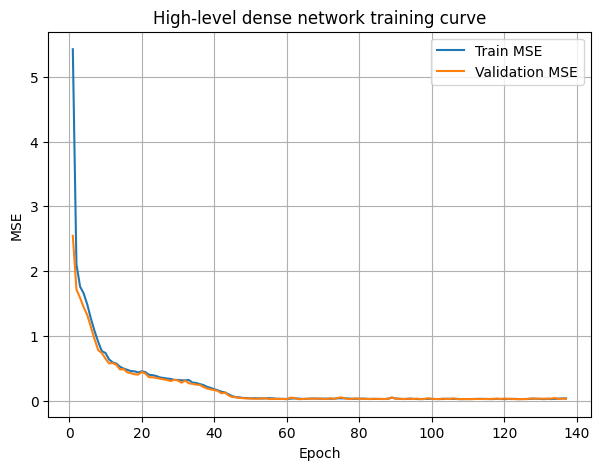

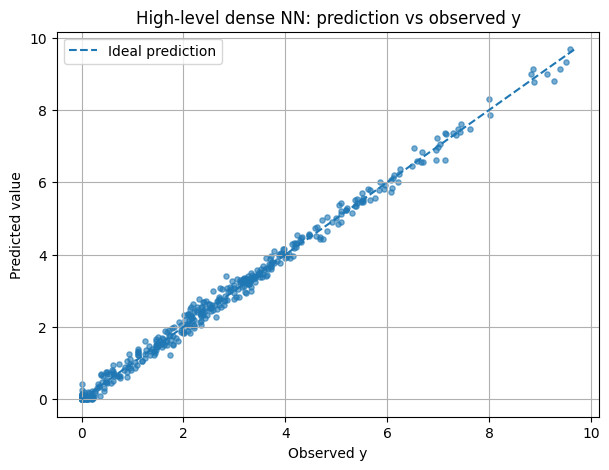

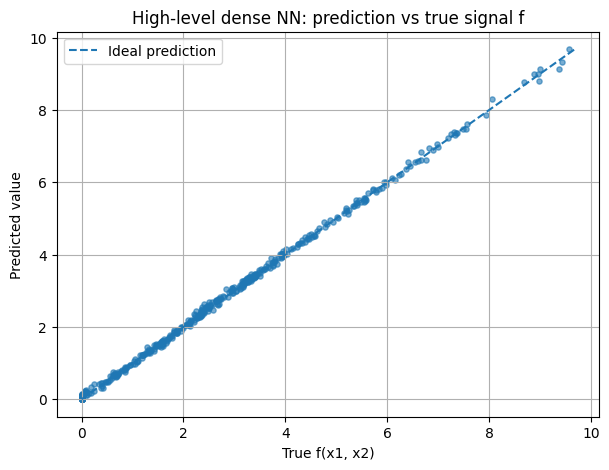

In [14]:
comparison_rows = [
    {
        "Model": "Manual 2-2-2-1 ReLU NN",
        "Parameters": count_parameters(manual_best["params"]),
        "Training time, s": manual_best["elapsed_seconds"],
        "Target compared": "observed y",
        **manual_metrics_observed,
    },
    {
        "Model": "Manual 2-2-2-1 ReLU NN",
        "Parameters": count_parameters(manual_best["params"]),
        "Training time, s": manual_best["elapsed_seconds"],
        "Target compared": "true f",
        **manual_metrics_true,
    },
]

if high_level_result is not None:
    high_metrics_observed = regression_metrics(y_test, high_level_result["prediction"])
    high_metrics_true = regression_metrics(f_test, high_level_result["prediction"])
    comparison_rows.extend(
        [
            {
                "Model": "High-level 2-32-32-1 ReLU NN",
                "Parameters": high_level_result["param_count"],
                "Training time, s": high_level_result["elapsed_seconds"],
                "Target compared": "observed y",
                **high_metrics_observed,
            },
            {
                "Model": "High-level 2-32-32-1 ReLU NN",
                "Parameters": high_level_result["param_count"],
                "Training time, s": high_level_result["elapsed_seconds"],
                "Target compared": "true f",
                **high_metrics_true,
            },
        ]
    )

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table)

if high_level_result is not None:
    plt.figure()
    plt.plot(high_level_result["history"]["epoch"], high_level_result["history"]["train_mse"], label="Train MSE")
    plt.plot(high_level_result["history"]["epoch"], high_level_result["history"]["val_mse"], label="Validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("High-level dense network training curve")
    plt.legend()
    plt.show()

    prediction_plot(
        y_test,
        high_level_result["prediction"],
        "High-level dense NN: prediction vs observed y",
        "Observed y",
    )
    prediction_plot(
        f_test,
        high_level_result["prediction"],
        "High-level dense NN: prediction vs true signal f",
        "True f(x1, x2)",
    )

## 3.19. Discussion and interpretation

The manual network satisfies the exact architecture required in the question: two input attributes, two hidden layers with two neurons each, one output neuron, and ReLU in all neurons. The forward pass, error computation, backpropagation signals, gradients, and parameter updates are explicitly implemented.

The manual model is interpretable because it has only 15 trainable parameters. Every matrix, bias vector, activation, delta, and gradient has a visible mathematical role. The finite-difference check provides numerical evidence that the implemented gradients match the derived objective $J$.

The limitation is capacity. The true signal contains a sinusoidal term $2\sin(\pi x_1)$, a quadratic term $0.75x_2^2$, an interaction term $-1.2x_1x_2$, and a nonnegative clipping operation. A 2-2-2-1 ReLU network represents a very small piecewise-linear function, so underfitting is expected. This should appear as higher test RMSE and more visible residual structure.

The high-level dense network has many more parameters and uses Adam. It therefore has better capacity to approximate curvature, oscillation, and interaction effects, and it usually reaches a lower validation and test error. However, its training dynamics are less transparent because the optimizer and automatic differentiation are delegated to the library.

Computational time is not determined only by parameter count. The manual network is tiny, but it is trained with explicit Python/NumPy full-batch updates and multiple restarts. The high-level model has more parameters, but the library uses optimized kernels and an adaptive optimizer. The relevant conceptual distinction is that the manual model is better for demonstrating first-principles backpropagation, while the high-level model is better as a predictive nonlinear regressor.

Final conclusion: the required manual network is correctly implemented and auditable, but it is intentionally capacity-limited. The high-level dense model is less interpretable but better suited to the nonlinear regression surface generated by the simulation.